# ChurnSense — Session 2: Exploratory Data Analysis

This notebook profiles the IBM Telco Customer Churn dataset, fixes the
`TotalCharges` dtype for analysis, measures churn patterns, and exports
decision-ready charts to `reports/`.

## tl;dr

- **Overall churn is 26.54%:** 1,869 of 7,043 customers churned, so accuracy alone would overstate model quality.
- **Contract term has the widest practical separation:** month-to-month customers churn at **42.71%**, versus **2.83%** for two-year customers.
- **Early tenure is the clearest lifecycle risk window:** customers at 0–12 months churn at **47.44%**, compared with **9.51%** at 49–72 months.
- **Fiber-optic customers have a 41.89% churn rate**, more than twice the **18.96%** rate for DSL customers.
- **Electronic-check customers churn at 45.29%**, versus **15.24%** among automatic credit-card customers.

These are descriptive associations, not evidence that any feature causes churn.

## Context & Methods

**Question.** Which customer, service, contract, and billing characteristics are most associated with churn in the supplied Telco dataset?

**Source.** `data/WA_Fn-UseC_-Telco-Customer-Churn.csv` — one row per customer, 7,043 customers, and 21 raw columns.

**Method.** Profile schema and data quality, convert `TotalCharges` to numeric, summarize the target, compare numeric distributions by churn status, compute churn rates for every categorical feature, and inspect numeric correlations.

### Key Assumptions

- `Churn = "Yes"` is encoded as 1 only for rate and correlation calculations.
- The 11 blank `TotalCharges` values are preserved as missing after numeric conversion; all occur at tenure 0 and will be handled in Session 3.
- `SeniorCitizen` is treated as categorical for segment rates even though it is stored as 0/1.
- Segment differences are observational and should not be interpreted causally.

## Data

### 1. Set up paths, libraries, and chart styling

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = project_root / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

COLORS = {
    "blue": "#2563EB",
    "blue_dark": "#1E3A8A",
    "orange": "#D97706",
    "orange_light": "#FDE7C3",
    "slate": "#475569",
    "slate_light": "#CBD5E1",
    "ink": "#172033",
    "grid": "#E2E8F0",
    "white": "#FFFFFF",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": COLORS["white"],
    "axes.facecolor": COLORS["white"],
    "axes.edgecolor": COLORS["slate"],
    "axes.labelcolor": COLORS["ink"],
    "axes.titlecolor": COLORS["ink"],
    "text.color": COLORS["ink"],
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.8,
    "font.size": 10,
})

def save_figure(fig, filename):
    output_path = reports_dir / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight", facecolor="white")
    return output_path

data_path, reports_dir

(WindowsPath('C:/Users/hp/Desktop/churnsense/data/WA_Fn-UseC_-Telco-Customer-Churn.csv'),
 WindowsPath('C:/Users/hp/Desktop/churnsense/reports'))

### 2. Load and verify the raw dataset

In [2]:
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path}")

df = pd.read_csv(data_path)

expected_shape = (7043, 21)
assert df.shape == expected_shape, f"Expected {expected_shape}, loaded {df.shape}"
assert df["customerID"].nunique() == len(df), "customerID should be unique"

df.shape

(7043, 21)

### 3. Preview customer-level records

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 4. Inspect raw columns, data types, and null counts

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 5. Convert `TotalCharges` from text to numeric

The raw column contains 11 whitespace-only strings. Coercing them to `NaN`
fixes the dtype without silently inventing values.

In [5]:
raw_total_charges_blanks = df["TotalCharges"].str.strip().eq("").sum()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
total_charges_missing = df["TotalCharges"].isna().sum()

assert raw_total_charges_blanks == 11
assert total_charges_missing == 11
assert df.loc[df["TotalCharges"].isna(), "tenure"].eq(0).all()

pd.DataFrame({
    "metric": [
        "Raw blank TotalCharges values",
        "Missing TotalCharges after conversion",
        "Tenure range (months)",
        "MonthlyCharges range",
    ],
    "value": [
        int(raw_total_charges_blanks),
        int(total_charges_missing),
        f"{df['tenure'].min()}–{df['tenure'].max()}",
        f"{df['MonthlyCharges'].min():.2f}–{df['MonthlyCharges'].max():.2f}",
    ],
})

,metric,value
0,Raw blank TotalCharges values,11
1,Missing TotalCharges after conversion,11
2,Tenure range (months),0–72
3,MonthlyCharges range,18.25–118.75


### 6. Run completeness, uniqueness, and range checks

In [6]:
data_quality_summary = pd.DataFrame({
    "check": [
        "Rows",
        "Columns",
        "Duplicate rows",
        "Duplicate customer IDs",
        "Raw null cells",
        "TotalCharges missing after numeric conversion",
        "Unexpected Churn labels",
    ],
    "value": [
        len(df),
        df.shape[1],
        int(df.duplicated().sum()),
        int(df["customerID"].duplicated().sum()),
        int(pd.read_csv(data_path).isna().sum().sum()),
        int(df["TotalCharges"].isna().sum()),
        int((~df["Churn"].isin(["Yes", "No"])).sum()),
    ],
})
data_quality_summary

,check,value
0,Rows,7043
1,Columns,21
2,Duplicate rows,0
3,Duplicate customer IDs,0
4,Raw null cells,0
5,TotalCharges missing after numeric conversion,11
6,Unexpected Churn labels,0


### Data issues found for preprocessing

1. **`TotalCharges` is stored as text** because 11 records contain blank strings. It is converted to numeric here, producing 11 missing values; all 11 customers have tenure 0.
2. **`customerID` is a unique identifier**, not a behavioral signal, so it should be excluded from model features.
3. **`SeniorCitizen` is semantically categorical** despite its integer dtype and should be encoded accordingly.
4. **The target is imbalanced:** 26.54% churned versus 73.46% retained. Use stratified splitting and recall/precision/F1/ROC-AUC rather than accuracy alone.
5. **Service-status labels are compound categories:** values such as `No internet service` and `No phone service` are valid states, not missing data, and require consistent encoding.

No duplicate rows, duplicate customer IDs, unexpected churn labels, or other raw null cells were found.

## Results

### 7. Measure the target distribution

In [7]:
df["ChurnFlag"] = df["Churn"].eq("Yes").astype(int)

churn_summary = (
    df["Churn"]
    .value_counts()
    .reindex(["No", "Yes"])
    .rename_axis("Churn")
    .reset_index(name="customers")
)
churn_summary["share_pct"] = (
    churn_summary["customers"].div(len(df)).mul(100).round(2)
)
churn_summary

,Churn,customers,share_pct
0,No,5174,73.46
1,Yes,1869,26.54


#### Customer counts by churn status

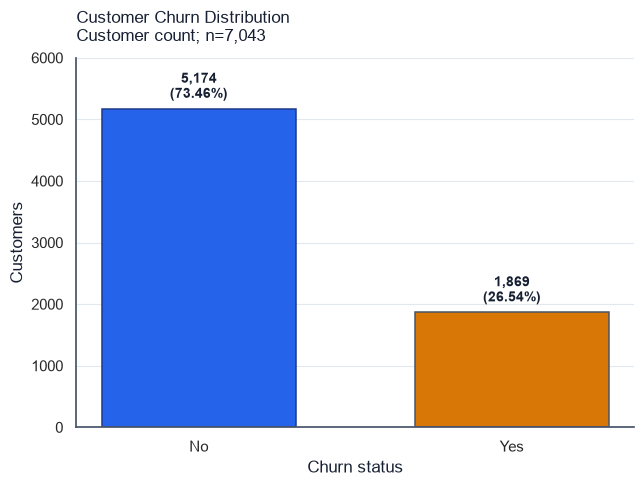

WindowsPath('C:/Users/hp/Desktop/churnsense/reports/01_churn_distribution_bar.png')

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
bars = ax.bar(
    churn_summary["Churn"],
    churn_summary["customers"],
    color=[COLORS["blue"], COLORS["orange"]],
    edgecolor=[COLORS["blue_dark"], COLORS["slate"]],
    linewidth=1.1,
    width=0.62,
)
ax.set_title("Customer Churn Distribution\nCustomer count; n=7,043", loc="left", pad=12)
ax.set_xlabel("Churn status")
ax.set_ylabel("Customers")
ax.set_ylim(0, churn_summary["customers"].max() * 1.16)
ax.grid(axis="x", visible=False)
for bar, share in zip(bars, churn_summary["share_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 110,
        f"{int(bar.get_height()):,}\n({share:.2f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
sns.despine(ax=ax)
bar_path = save_figure(fig, "01_churn_distribution_bar.png")
plt.show()
bar_path

#### Customer mix by churn status

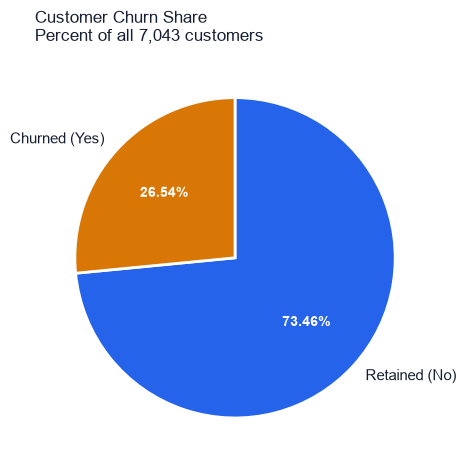

WindowsPath('C:/Users/hp/Desktop/churnsense/reports/02_churn_distribution_pie.png')

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
wedges, labels, percentages = ax.pie(
    churn_summary["customers"],
    labels=["Retained (No)", "Churned (Yes)"],
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False,
    colors=[COLORS["blue"], COLORS["orange"]],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"color": COLORS["ink"]},
)
for percentage in percentages:
    percentage.set_color("white")
    percentage.set_fontweight("bold")
ax.set_title("Customer Churn Share\nPercent of all 7,043 customers", loc="left", pad=12)
pie_path = save_figure(fig, "02_churn_distribution_pie.png")
plt.show()
pie_path

### 8. Compare tenure and monthly-charge distributions

In [10]:
numeric_summary_by_churn = (
    df.groupby("Churn")
    .agg(
        customers=("customerID", "size"),
        median_tenure=("tenure", "median"),
        mean_tenure=("tenure", "mean"),
        median_monthly_charges=("MonthlyCharges", "median"),
        mean_monthly_charges=("MonthlyCharges", "mean"),
        median_total_charges=("TotalCharges", "median"),
    )
    .round(2)
    .reindex(["No", "Yes"])
)
numeric_summary_by_churn

,customers,median_tenure,mean_tenure,median_monthly_charges,mean_monthly_charges,median_total_charges
Churn,,,,,,
No,5174,38.0,37.57,64.43,61.27,1683.60
Yes,1869,10.0,17.98,79.65,74.44,703.55


In [11]:
tenure_bins = [-1, 12, 24, 48, 72]
tenure_labels = ["0–12 months", "13–24 months", "25–48 months", "49–72 months"]
df["tenure_band"] = pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels)

tenure_band_summary = (
    df.groupby("tenure_band", observed=True)
    .agg(customers=("customerID", "size"), churned=("ChurnFlag", "sum"), churn_rate=("ChurnFlag", "mean"))
    .reset_index()
)
tenure_band_summary["churn_rate_pct"] = tenure_band_summary["churn_rate"].mul(100).round(2)
tenure_band_summary.drop(columns="churn_rate")

,tenure_band,customers,churned,churn_rate_pct
0,0–12 months,2186,1037,47.44
1,13–24 months,1024,294,28.71
2,25–48 months,1594,325,20.39
3,49–72 months,2239,213,9.51


#### Tenure distribution by churn status

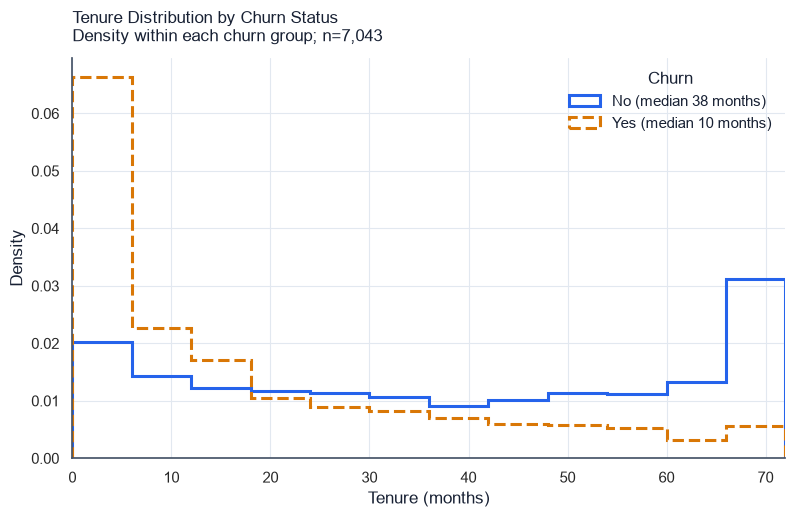

WindowsPath('C:/Users/hp/Desktop/churnsense/reports/03_tenure_distribution_by_churn.png')

In [12]:
fig, ax = plt.subplots(figsize=(9.2, 5.2))
histogram_specs = [
    ("No", COLORS["blue"], "-"),
    ("Yes", COLORS["orange"], "--"),
]
for churn_status, color, line_style in histogram_specs:
    values = df.loc[df["Churn"].eq(churn_status), "tenure"]
    ax.hist(
        values,
        bins=np.arange(0, 78, 6),
        density=True,
        histtype="step",
        linewidth=2.2,
        linestyle=line_style,
        color=color,
        label=f"{churn_status} (median {values.median():.0f} months)",
    )
ax.set_title("Tenure Distribution by Churn Status\nDensity within each churn group; n=7,043", loc="left", pad=12)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Density")
ax.set_xlim(0, 72)
ax.legend(title="Churn", frameon=False)
sns.despine(ax=ax)
tenure_path = save_figure(fig, "03_tenure_distribution_by_churn.png")
plt.show()
tenure_path

#### Monthly-charge distribution by churn status

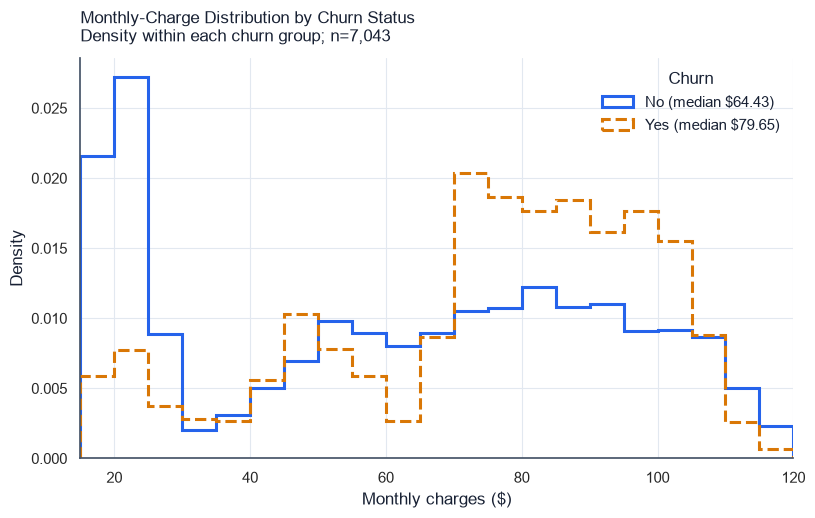

WindowsPath('C:/Users/hp/Desktop/churnsense/reports/04_monthly_charges_distribution_by_churn.png')

In [13]:
fig, ax = plt.subplots(figsize=(9.2, 5.2))
for churn_status, color, line_style in histogram_specs:
    values = df.loc[df["Churn"].eq(churn_status), "MonthlyCharges"]
    ax.hist(
        values,
        bins=np.arange(15, 126, 5),
        density=True,
        histtype="step",
        linewidth=2.2,
        linestyle=line_style,
        color=color,
        label=f"{churn_status} (median ${values.median():.2f})",
    )
ax.set_title("Monthly-Charge Distribution by Churn Status\nDensity within each churn group; n=7,043", loc="left", pad=12)
ax.set_xlabel("Monthly charges ($)")
ax.set_ylabel("Density")
ax.set_xlim(15, 120)
ax.legend(title="Churn", frameon=False)
sns.despine(ax=ax)
monthly_path = save_figure(fig, "04_monthly_charges_distribution_by_churn.png")
plt.show()
monthly_path

### 9. Compute churn rate for every categorical feature

In [14]:
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
categorical_features = [
    "gender", "SeniorCitizenLabel", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

rate_frames = []
for feature in categorical_features:
    feature_rates = (
        df.groupby(feature, dropna=False)
        .agg(customers=("customerID", "size"), churned=("ChurnFlag", "sum"), churn_rate=("ChurnFlag", "mean"))
        .reset_index()
        .rename(columns={feature: "category"})
    )
    feature_rates.insert(0, "feature", feature)
    feature_rates["churn_rate_pct"] = feature_rates["churn_rate"].mul(100).round(2)
    rate_frames.append(feature_rates.drop(columns="churn_rate"))

categorical_churn_rates = pd.concat(rate_frames, ignore_index=True)
categorical_rates_path = reports_dir / "categorical_churn_rates.csv"
categorical_churn_rates.to_csv(categorical_rates_path, index=False)

categorical_churn_rates

,feature,category,customers,churned,churn_rate_pct
0,gender,Female,3488,939,26.92
1,gender,Male,3555,930,26.16
2,SeniorCitizenLabel,No,5901,1393,23.61
3,SeniorCitizenLabel,Yes,1142,476,41.68
4,Partner,No,3641,1200,32.96
5,Partner,Yes,3402,669,19.66
6,Dependents,No,4933,1543,31.28
7,Dependents,Yes,2110,326,15.45
8,PhoneService,No,682,170,24.93
9,PhoneService,Yes,6361,1699,26.71


In [15]:
feature_spread = (
    categorical_churn_rates.groupby("feature")
    .agg(
        lowest_rate_pct=("churn_rate_pct", "min"),
        highest_rate_pct=("churn_rate_pct", "max"),
        rate_gap_pp=("churn_rate_pct", lambda values: values.max() - values.min()),
    )
    .sort_values("rate_gap_pp", ascending=False)
    .round(2)
)
feature_spread

,lowest_rate_pct,highest_rate_pct,rate_gap_pp
feature,,,
Contract,2.83,42.71,39.88
InternetService,7.40,41.89,34.49
OnlineSecurity,7.40,41.77,34.37
TechSupport,7.40,41.64,34.24
OnlineBackup,7.40,39.93,32.53
DeviceProtection,7.40,39.13,31.73
PaymentMethod,15.24,45.29,30.05
StreamingMovies,7.40,33.68,26.28
StreamingTV,7.40,33.52,26.12


In [16]:
overall_churn_rate_pct = df["ChurnFlag"].mean() * 100

def plot_categorical_churn_rate(feature, filename, title):
    plot_data = (
        categorical_churn_rates.loc[categorical_churn_rates["feature"].eq(feature)]
        .sort_values("churn_rate_pct")
        .copy()
    )
    fig, ax = plt.subplots(figsize=(9.4, max(4.2, 0.72 * len(plot_data) + 2.2)))
    bars = ax.barh(
        plot_data["category"].astype(str),
        plot_data["churn_rate_pct"],
        color=COLORS["blue"],
        edgecolor=COLORS["blue_dark"],
        linewidth=1,
    )
    ax.axvline(
        overall_churn_rate_pct,
        color=COLORS["slate"],
        linestyle="--",
        linewidth=1.4,
        label=f"Overall {overall_churn_rate_pct:.2f}%",
    )
    ax.set_title(f"{title}\nPercent churned; bar labels include segment size", loc="left", pad=12)
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, min(100, plot_data["churn_rate_pct"].max() + 13))
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right", frameon=False)
    for bar, rate, customers in zip(bars, plot_data["churn_rate_pct"], plot_data["customers"]):
        ax.text(
            rate + 0.7,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.2f}% · n={customers:,}",
            va="center",
            fontsize=9,
        )
    sns.despine(ax=ax)
    output_path = save_figure(fig, filename)
    plt.show()
    return output_path

#### Contract churn rates

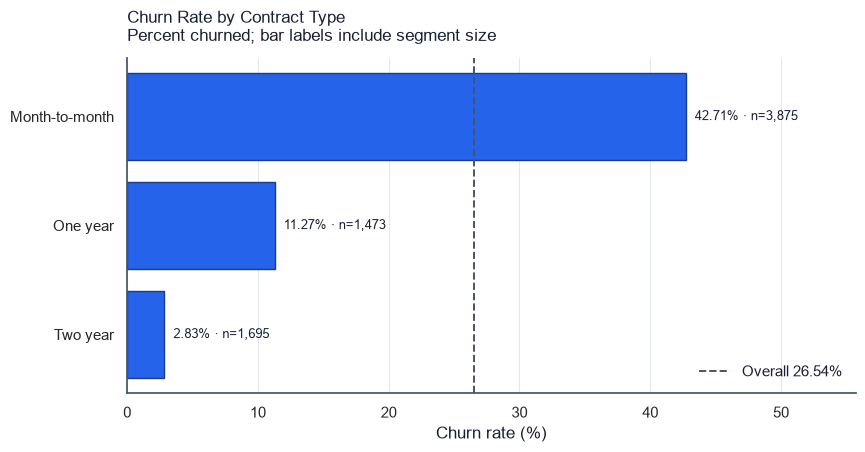

WindowsPath('C:/Users/hp/Desktop/churnsense/reports/05_churn_rate_by_contract.png')

In [17]:
contract_path = plot_categorical_churn_rate(
    "Contract",
    "05_churn_rate_by_contract.png",
    "Churn Rate by Contract Type",
)
contract_path

#### Internet-service churn rates

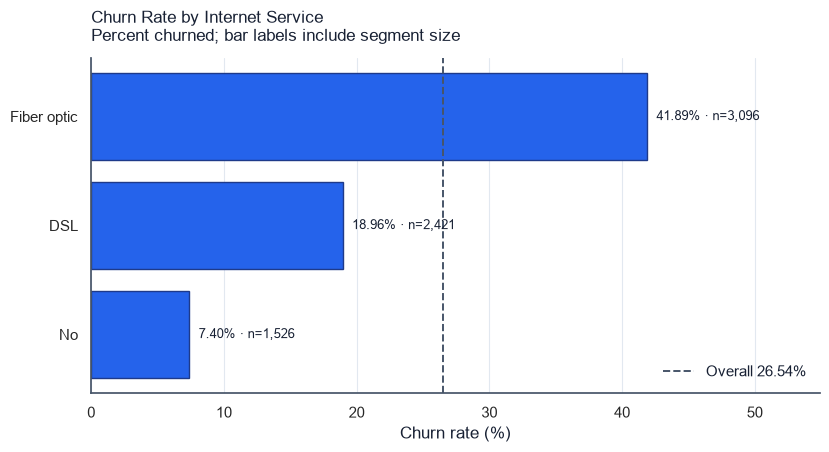

WindowsPath('C:/Users/hp/Desktop/churnsense/reports/06_churn_rate_by_internet_service.png')

In [18]:
internet_path = plot_categorical_churn_rate(
    "InternetService",
    "06_churn_rate_by_internet_service.png",
    "Churn Rate by Internet Service",
)
internet_path

#### Payment-method churn rates

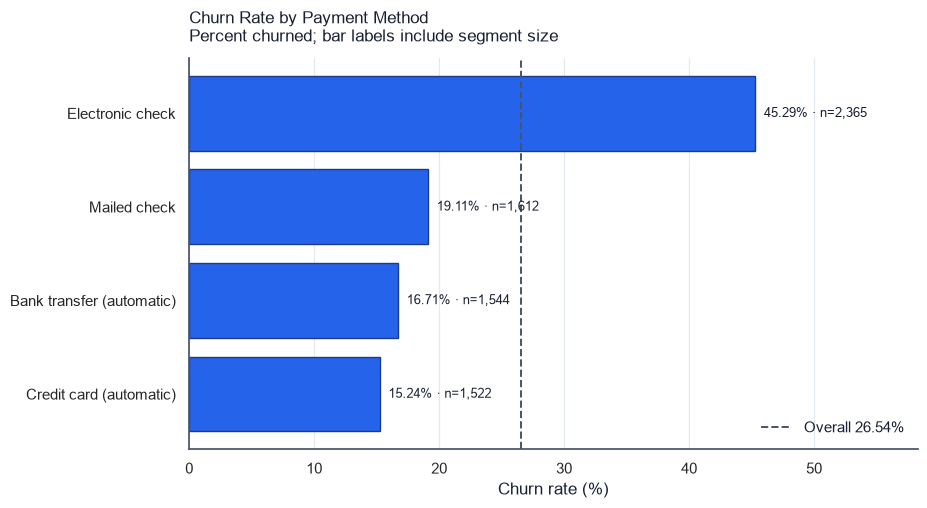

WindowsPath('C:/Users/hp/Desktop/churnsense/reports/07_churn_rate_by_payment_method.png')

In [19]:
payment_path = plot_categorical_churn_rate(
    "PaymentMethod",
    "07_churn_rate_by_payment_method.png",
    "Churn Rate by Payment Method",
)
payment_path

### 10. Inspect numeric correlations

Pearson correlations summarize linear association only. They do not
capture non-linear patterns or establish causality.

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnFlag
SeniorCitizen,1.00,0.02,0.22,0.10,0.15
tenure,0.02,1.00,0.25,0.83,-0.35
MonthlyCharges,0.22,0.25,1.00,0.65,0.19
TotalCharges,0.10,0.83,0.65,1.00,-0.20
ChurnFlag,0.15,-0.35,0.19,-0.20,1.00


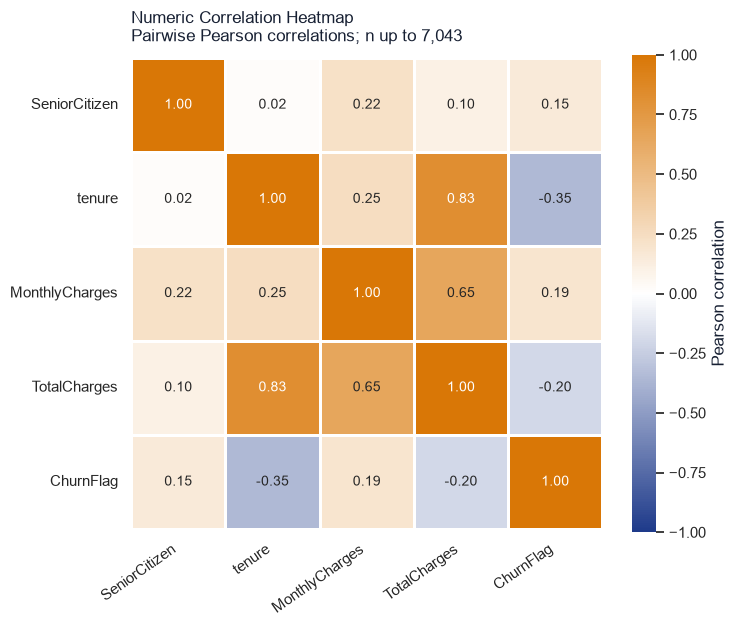

WindowsPath('C:/Users/hp/Desktop/churnsense/reports/08_numeric_correlation_heatmap.png')

In [20]:
numeric_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]
correlation_matrix = df[numeric_columns].corr()
display(correlation_matrix.round(2))

correlation_cmap = LinearSegmentedColormap.from_list(
    "blue_white_orange",
    [COLORS["blue_dark"], COLORS["white"], COLORS["orange"]],
)
fig, ax = plt.subplots(figsize=(7.6, 6.2))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=correlation_cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Numeric Correlation Heatmap\nPairwise Pearson correlations; n up to 7,043", loc="left", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
correlation_path = save_figure(fig, "08_numeric_correlation_heatmap.png")
plt.show()
correlation_path

## Takeaways

### Five business insights

1. **Contract commitment separates risk sharply.** Month-to-month customers churn at **42.71%** (1,655 of 3,875), compared with **11.27%** for one-year and **2.83%** for two-year contracts. Retention teams should prioritize month-to-month customers for targeted offers, while testing rather than assuming that longer contracts cause retention.
2. **The first year is the most exposed lifecycle stage.** Customers with 0–12 months of tenure churn at **47.44%**, versus **9.51%** among customers at 49–72 months. Churned customers have a median tenure of **10 months**, compared with **38 months** for retained customers.
3. **Churners carry higher recurring charges.** Median monthly charges are **$79.65** for churned customers versus **$64.43** for retained customers, a **$15.22** difference. Pricing, perceived value, and plan fit deserve follow-up analysis.
4. **Fiber-optic customers form a high-risk service segment.** Their churn rate is **41.89%** (1,297 of 3,096), versus **18.96%** for DSL and **7.40%** for customers without internet service. Service experience and pricing should be investigated before drawing a causal conclusion.
5. **Electronic-check customers show elevated churn.** Their churn rate is **45.29%** (1,071 of 2,365), versus **15.24%** for automatic credit-card and **16.71%** for automatic bank-transfer customers. Payment method may also proxy for contract type or customer mix, so multivariate modeling is needed.

### Implications for Session 3

- Exclude `customerID` from model features.
- Decide and document how to handle the 11 missing numeric `TotalCharges` values.
- Encode categorical columns, including the categorical meaning of `SeniorCitizen`.
- Use a stratified split and imbalance-aware evaluation metrics.
- Preserve compound service states consistently during encoding.

### 11. Reconcile headline claims and exported artifacts

In [21]:
def segment_rate(feature, category):
    row = categorical_churn_rates.loc[
        categorical_churn_rates["feature"].eq(feature)
        & categorical_churn_rates["category"].astype(str).eq(str(category)),
        "churn_rate_pct",
    ]
    assert len(row) == 1
    return float(row.iloc[0])

assert round(df["ChurnFlag"].mean() * 100, 2) == 26.54
assert segment_rate("Contract", "Month-to-month") == 42.71
assert segment_rate("Contract", "Two year") == 2.83
assert tenure_band_summary.loc[0, "churn_rate_pct"] == 47.44
assert tenure_band_summary.loc[3, "churn_rate_pct"] == 9.51
assert numeric_summary_by_churn.loc["Yes", "median_tenure"] == 10.00
assert numeric_summary_by_churn.loc["No", "median_tenure"] == 38.00
assert numeric_summary_by_churn.loc["Yes", "median_monthly_charges"] == 79.65
assert numeric_summary_by_churn.loc["No", "median_monthly_charges"] == 64.43
assert segment_rate("InternetService", "Fiber optic") == 41.89
assert segment_rate("InternetService", "DSL") == 18.96
assert segment_rate("PaymentMethod", "Electronic check") == 45.29
assert segment_rate("PaymentMethod", "Credit card (automatic)") == 15.24
assert categorical_churn_rates["feature"].nunique() == len(categorical_features)

expected_charts = [
    "01_churn_distribution_bar.png",
    "02_churn_distribution_pie.png",
    "03_tenure_distribution_by_churn.png",
    "04_monthly_charges_distribution_by_churn.png",
    "05_churn_rate_by_contract.png",
    "06_churn_rate_by_internet_service.png",
    "07_churn_rate_by_payment_method.png",
    "08_numeric_correlation_heatmap.png",
]
missing_or_empty = [
    name for name in expected_charts
    if not (reports_dir / name).exists() or (reports_dir / name).stat().st_size < 10_000
]
assert not missing_or_empty, f"Missing or empty chart files: {missing_or_empty}"
assert categorical_rates_path.exists() and categorical_rates_path.stat().st_size > 1_000

pd.DataFrame({
    "validation_check": [
        "Notebook headline calculations",
        "Categorical features profiled",
        "Exported chart files",
        "Categorical-rate CSV",
    ],
    "result": [
        "Passed",
        f"Passed ({len(categorical_features)} features)",
        f"Passed ({len(expected_charts)} charts)",
        "Passed",
    ],
})

,validation_check,result
0,Notebook headline calculations,Passed
1,Categorical features profiled,Passed (16 features)
2,Exported chart files,Passed (8 charts)
3,Categorical-rate CSV,Passed
